hai sa facem primul task

In [1]:
import torch
import torch.nn as nn
import torchvision.models as models
import pandas as pd
import sys
import os


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


print("Loading model...")

try:
    model = models.resnet18(weights=None)
    # Modify input layer (as per template)
    model.conv1 = torch.nn.Conv2d(3, 64, kernel_size=5, stride=1, padding=3, bias=False)
    # Modify output layer (as per template: Dropout + 9 Classes)
    model.fc = torch.nn.Sequential(
        torch.nn.Dropout(p=0.2),
        torch.nn.Linear(model.fc.in_features, 9)
    )
    
    # Load weights
    model.load_state_dict(torch.load("classifier.pt", map_location=device))
    model.to(device)
    model.eval() # Important: Set to evaluation mode for consistent inference
    print("✅ Model loaded successfully.")

except FileNotFoundError:
    print("❌ Error: 'classifier.pt' not found. Make sure it is in this folder.")
    sys.exit(1)

Using device: cuda
Loading model...
✅ Model loaded successfully.


In [3]:
print("Loading dataset (this might take a moment)...")
try:
    dataset = torch.load("subsets_dataset.pt")
    print(f"✅ Dataset loaded. Found {len(dataset)} subsets.")
except FileNotFoundError:
    print("❌ Error: 'subsets_dataset.pt' not found.")
    sys.exit(1)

Loading dataset (this might take a moment)...
✅ Dataset loaded. Found 1000 subsets.


blind walk method

In [10]:
def get_distance_to_boundary(model, images, labels, max_steps=1000, noise_scale=0.005):
    """
    Adds noise to images step-by-step until the prediction flips.
    Returns the average steps taken.
    """
    # Create a noise vector (random direction)
    noise = torch.randn_like(images).to(device) * noise_scale
    
    # Current state of images
    current_images = images.clone()
    
    # Track which images have NOT flipped yet (mask)
    active_mask = torch.ones(images.size(0), dtype=torch.bool, device=device)
    
    # Track distances (steps taken)
    distances = torch.zeros(images.size(0), device=device)
    
    with torch.no_grad():
        original_preds = labels # We assume original labels are correct
        
        for step in range(max_steps):
            # 1. Move one step in the random direction
            current_images[active_mask] += noise[active_mask]
            
            # 2. Predict
            outputs = model(current_images[active_mask])
            preds = outputs.argmax(dim=1)
            
            # 3. Check for flips
            # If pred != original_label, it flipped!
            flipped_now = (preds != original_preds[active_mask])
            
            # 4. Update distances for flipped images
            # (We find the indices in the original batch that correspond to the currently active ones)
            active_indices = torch.nonzero(active_mask).squeeze()
            
            if flipped_now.any():
                # Get indices of images that just flipped
                just_flipped_indices = active_indices[flipped_now] if active_indices.ndim > 0 else active_indices
                
                # Record the step count
                distances[just_flipped_indices] = step
                
                # Remove them from the active set
                if active_indices.ndim == 0: # Handle single item case
                     active_mask = torch.tensor(False, device=device)
                else:
                    active_mask[active_indices[flipped_now]] = False
            
            # If all images have flipped, stop early
            if not active_mask.any():
                break
                
    # If some didn't flip, give them the max score
    distances[active_mask] = max_steps
    return distances.mean().item()

In [11]:

results = []
criterion = nn.CrossEntropyLoss()

for i in range(1000):
    subset = dataset[f"subset_{i}"]
    
    # OPTIMIZATION: Only use first 25 images to speed it up. 
    # 25 is enough to get a statistical average.
    images = subset["images"][:25].to(device) 
    labels = subset["labels"][:25].to(device)
    
    # Calculate distance
    avg_dist = get_distance_to_boundary(model, images, labels)
    
    # Score Logic:
    # Training Data = Far from boundary = High Distance
    # We want HIGH score for members.
    membership_score = avg_dist 
    
    results.append({
        "subset_id": i,
        "membership": membership_score
    })
    
    if i % 10 == 0:
        print(f"Subset {i}: Dist {avg_dist:.2f}")



Subset 0: Dist 5.84
Subset 10: Dist 12.16
Subset 20: Dist 7.04
Subset 30: Dist 10.04
Subset 40: Dist 9.88
Subset 50: Dist 43.76
Subset 60: Dist 11.36
Subset 70: Dist 39.20
Subset 80: Dist 12.80
Subset 90: Dist 10.76
Subset 100: Dist 9.04
Subset 110: Dist 8.24
Subset 120: Dist 7.20
Subset 130: Dist 7.68
Subset 140: Dist 9.24
Subset 150: Dist 8.76
Subset 160: Dist 6.48
Subset 170: Dist 13.08
Subset 180: Dist 12.56
Subset 190: Dist 7.44
Subset 200: Dist 11.60
Subset 210: Dist 8.12
Subset 220: Dist 11.68
Subset 230: Dist 9.92
Subset 240: Dist 4.24
Subset 250: Dist 9.20
Subset 260: Dist 7.40
Subset 270: Dist 6.16
Subset 280: Dist 9.68
Subset 290: Dist 50.16
Subset 300: Dist 8.96
Subset 310: Dist 13.36
Subset 320: Dist 11.80
Subset 330: Dist 10.64
Subset 340: Dist 9.20
Subset 350: Dist 8.68
Subset 360: Dist 11.52
Subset 370: Dist 12.32
Subset 380: Dist 22.00
Subset 390: Dist 9.04
Subset 400: Dist 7.28
Subset 410: Dist 5.64
Subset 420: Dist 7.28
Subset 430: Dist 9.16
Subset 440: Dist 7.20
Sub

In [12]:
df = pd.DataFrame(results)

# Safety check: Ensure 1000 rows
if len(df) != 1000:
    print(f"⚠️ Warning: Expected 1000 rows, but generated {len(df)}.")

# Save to CSV
output_filename = "submission_loss_method.csv"
df.to_csv(output_filename, index=False)

print(f"\n✅ Inference Complete!")
print(f"Saved results to: {output_filename}")
print("\nTop 5 rows of your submission:")
print(df.head())


✅ Inference Complete!
Saved results to: submission_loss_method.csv

Top 5 rows of your submission:
   subset_id  membership
0          0    5.840000
1          1   11.240000
2          2    6.880000
3          3    8.559999
4          4   49.480000


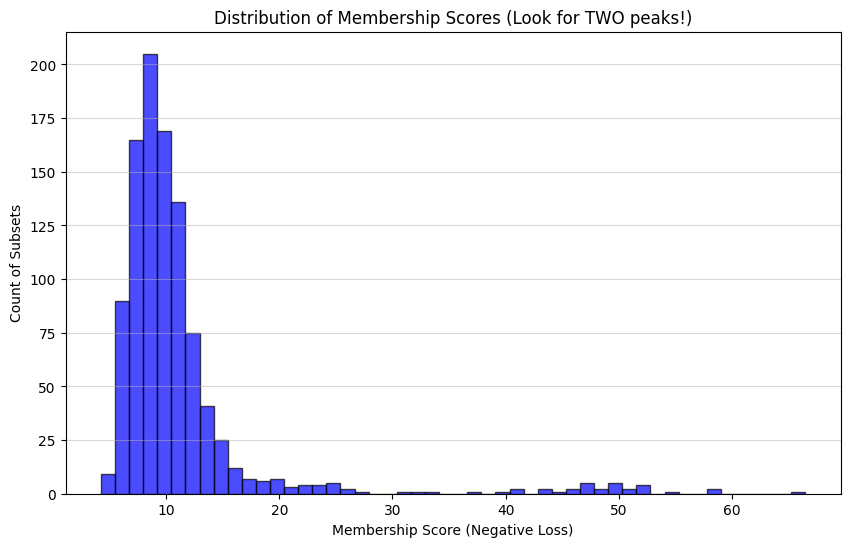

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

# Load your submission file
df = pd.read_csv("submission_loss_method.csv")

# Plot the Histogram
plt.figure(figsize=(10, 6))
plt.hist(df['membership'], bins=50, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of Membership Scores (Look for TWO peaks!)')
plt.xlabel('Membership Score (Negative Loss)')
plt.ylabel('Count of Subsets')
plt.grid(axis='y', alpha=0.5)
plt.show()